In [1]:
import pandas as pd
import geopandas as gpd

import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pygeotools.lib import geolib

In [16]:
def make_plot3d(x, y, z, title_fig=None,clim=None,out_fn=None,figsize=(10,4)):
    #from David Shean
    cmean = np.mean([x,y,z], axis=1)
    cmed = np.median([x,y,z], axis=1)

    #ax.scatter(cmean[0], cmean[1], cmean[2], color='r', marker='s')

    ce90 = geolib.CE90(x,y)
    le90 = geolib.LE90(z)
    coefs = [ce90, ce90, le90]
    #ax.set_title("CE90: %0.2f, LE90: %0.2f, n=%i" % (ce90, le90, x.shape[0])) 
    
    maxdim = np.ceil(np.max([np.max(np.abs([x, y, z])), ce90, le90]))
    
    from matplotlib.patches import Ellipse
    fig_ortho = plt.figure(figsize=figsize)
    #fig_ortho = plt.figure()
    if title_fig:
        title=title_fig+'\nn=%i, mean: (%0.2f, %0.2f, %0.2f)\nCE90: %0.2f, LE90: %0.2f' % (x.shape[0], cmean[0], cmean[1], cmean[2], ce90, le90)
    else:
        title = 'n=%i, mean: (%0.2f, %0.2f, %0.2f)\nCE90: %0.2f, LE90: %0.2f' % (x.shape[0], cmean[0], cmean[1], cmean[2], ce90, le90)
    plt.suptitle(title) 

    if clim:
        out_clim = clim
    else:
        out_clim = (-maxdim,maxdim)
    ax = fig_ortho.add_subplot(131)
    ax.plot(x, y, color='b', linestyle='None', marker='o', label='Alignment vectors')
    ax.plot(cmean[0], cmean[1], color='r', linestyle='None', marker='s', label='Mean')
    #ax.scatter(x, y)
    #ax.scatter(cmean[0], cmean[1], color='r', marker='s')
    ax.set_xlim(out_clim)
    ax.set_ylim(out_clim)
    ax.minorticks_on()
    ax.set_aspect('equal')
    ax.set_xlabel('X offset (m)')
    ax.set_ylabel('Y offset (m)')
    e = Ellipse((0,0), 2*ce90, 2*ce90, linewidth=0, alpha=0.1)
    ax.add_artist(e)
    plt.legend(prop={'size':8}, numpoints=1, loc='upper left')

    ax = fig_ortho.add_subplot(132)
    ax.plot(x, z, color='b', linestyle='None', marker='o', label='Alignment vectors')
    ax.plot(cmean[0], cmean[2], color='r', linestyle='None', marker='s', label='Mean')
    #ax.scatter(x, z)
    #ax.scatter(cmean[0], cmean[2], color='r', marker='s')
    ax.set_xlim(out_clim)
    ax.set_ylim(out_clim)
    ax.minorticks_on()
    ax.set_aspect('equal')
    ax.set_xlabel('X offset (m)')
    ax.set_ylabel('Z offset (m)')
    e = Ellipse((0,0), 2*ce90, 2*le90, linewidth=0, alpha=0.1)
    ax.add_artist(e)

    ax = fig_ortho.add_subplot(133)
    ax.plot(y, z, color='b', linestyle='None', marker='o', label='Alignment vectors')
    ax.plot(cmean[1], cmean[2], color='r', linestyle='None', marker='s', label='Mean')
    #ax.scatter(y, z)
    #ax.scatter(cmean[1], cmean[2], color='r', marker='s')
    
    ax.set_xlim(out_clim)
    ax.set_ylim(out_clim)
    ax.minorticks_on()
    ax.set_aspect('equal')
    ax.set_xlabel('Y offset (m)')
    ax.set_ylabel('Z offset (m)')
    e = Ellipse((0,0), 2*ce90, 2*le90, linewidth=0, alpha=0.1)
    ax.add_artist(e)
    
    plt.tight_layout()
    if out_fn:
        plt.savefig(out_fn,dpi=300,bbox_inches='tight')
    #Note: postscript doesn't properly handle tansparency
    #fig_fn = 'icp_translation_vec_proj_meters_orthogonal.pdf'
    #fig_fn = 'icp_translation_vec_local_meters_orthogonal.pdf'
    #plt.savefig(fig_fn, dpi=600, bbox_inches='tight')

#Set back to original figure
#plt.figure(fig.number)

In [17]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration


In [18]:
def fetch_stereo_vector(fn):
    dx = fn.split('dx')[1].split('m_dy')[0]
    dy = fn.split('dy')[1].split('m_dz')[0]
    dz = fn.split('dz')[1].split('m')[0]
    return (float(dx),float(dy),float(dz))

In [19]:
stereo_dem_fns = sorted(glob.glob('usgs/*processing/stereo*/*-DEM*.tif'))+ sorted(glob.glob('neon/*processing/stereo*/*-DEM*.tif')) + sorted(glob.glob('ncalm/*processing/stereo*/*-DEM*.tif'))

In [20]:
len(stereo_dem_fns)

16

In [21]:
stereo_dx = []
stereo_dy = []
stereo_dz = []
for stereo_dem in stereo_dem_fns:
    dx,dy,dz = fetch_stereo_vector(stereo_dem)
    stereo_dx.append(dx)
    stereo_dy.append(dy)
    stereo_dz.append(dz)
stereo_dx = np.array(stereo_dx)
stereo_dy = np.array(stereo_dy)
stereo_dz = np.array(stereo_dz)

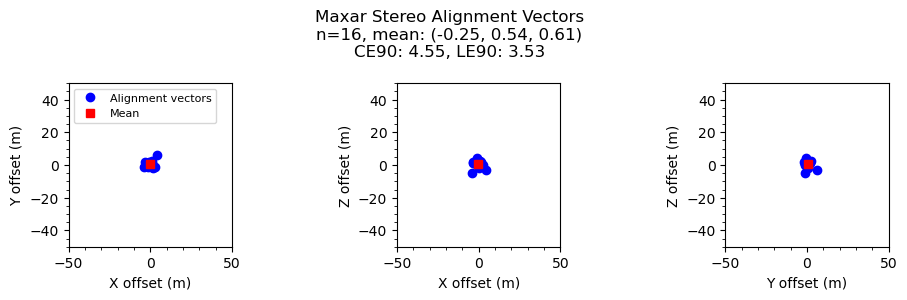

In [24]:
make_plot3d(stereo_dx,stereo_dy,stereo_dz,title_fig=f'Maxar Stereo Alignment Vectors',clim=(-50,50),out_fn='/home/sbhusha1/notebooks/pcd/stereo_ce90.png',figsize=(10,3))

In [25]:
sameple_icesat2_fn = ('usgs/AZ_PimaCo_2_2021_processing/ICESat-2_SR/AZ_PimaCo_2_2021-coreg_shift_vector.geojson')
fn = sameple_icesat2_fn
def fetch_is2_vector(fn):
    gdf  = gpd.read_file(fn)

    dx = gdf['dx_east_m'].values[0]
    dy = gdf['dy_north_m'].values[0]
    dz = gdf['dz_up_m'].values[0]
    return (dx,dy,dz)

In [26]:
is2_fns = sorted(glob.glob('usgs/*processing/ICESat-2_SR/*coreg_shift_vector.geojson')) + sorted(glob.glob('neon/*processing/ICESat-2_SR/*coreg_shift_vector.geojson')) + sorted(glob.glob('ncalm/*processing/ICESat-2_SR/*coreg_shift_vector.geojson'))

In [27]:
len(is2_fns)

13

In [28]:
is2_dx = []
is2_dy = []
is2_dz = []
for is2 in is2_fns:
    dx,dy,dz = fetch_is2_vector(is2)
    is2_dx.append(dx)
    is2_dy.append(dy)
    is2_dz.append(dz)
is2_dx = np.array(is2_dx)
is2_dy = np.array(is2_dy)
is2_dz = np.array(is2_dz)

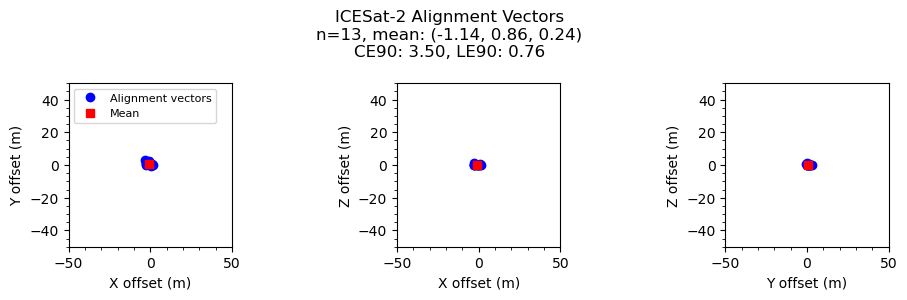

In [30]:
#make_plot3d(is2_dx,is2_dy,is2_dz,title_fig=f'ICESat-2 Alignment Vectors',clim=(-50,50))
make_plot3d(is2_dx,is2_dy,is2_dz,title_fig=f'ICESat-2 Alignment Vectors',clim=(-50,50),out_fn='/home/sbhusha1/notebooks/pcd/is2_ce90.png',figsize=(10,3))

In [31]:
sample_gedi_fn = ('usgs/WY_FEMA_East_B9_2019_processing/GEDI/coreg_shift_vectors.geojson')
fn = sample_gedi_fn
def fetch_gedi_vector(fn):
    gdf = gpd.read_file(fn)
    gdf.dropna(inplace=True)

    dx = gdf['dx_east_m'].values
    dy = gdf['dy_north_m'].values
    dz = gdf['dz_up_m'].values
    return (dx,dy,dz)

In [32]:
gedi_fns = sorted(glob.glob('usgs/*processing/GEDI/coreg_shift_vectors.geojson')) + sorted(glob.glob('neon/*processing/GEDI/coreg_shift_vectors.geojson')) + sorted(glob.glob('ncalm/*processing/GEDI/coreg_shift_vectors.geojson'))

In [33]:
gedi_dx = []
gedi_dy = []
gedi_dz = []
for gedi in gedi_fns:
    dx,dy,dz = fetch_gedi_vector(gedi)
    gedi_dx.append(dx)
    gedi_dy.append(dy)
    gedi_dz.append(dz)
gedi_dx = np.concatenate(gedi_dx, axis=0)
gedi_dy = np.concatenate(gedi_dy, axis=0)
gedi_dz = np.concatenate(gedi_dz, axis=0)

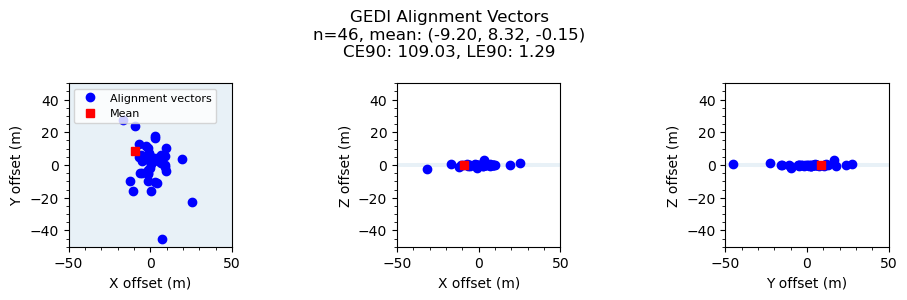

In [34]:
#make_plot3d(gedi_dx,gedi_dy,gedi_dz,title_fig=f'GEDI Alignment Vectors',clim=(-50,50))
make_plot3d(gedi_dx,gedi_dy,gedi_dz,title_fig=f'GEDI Alignment Vectors',clim=(-50,50),out_fn='/home/sbhusha1/notebooks/pcd/gedi_ce90.png',figsize=(10,3))

In [44]:
mask = np.where(np.abs(gedi_dy)>40)[0]
filter_gedi_dx = np.delete(gedi_dx,mask)
filter_gedi_dy = np.delete(gedi_dy,mask)
filter_gedi_dz = np.delete(gedi_dz,mask)

In [45]:
mask

array([10, 11, 13, 35])

In [46]:
np.sort

<function sort at 0x154e253314b0>

In [47]:
np.sort(filter_gedi_dy)

array([-22.687789  , -15.802469  , -15.626328  , -11.13712   ,
       -10.339349  ,  -9.9079764 ,  -9.7277103 ,  -5.7825837 ,
        -4.9603733 ,  -4.893299  ,  -4.6567591 ,  -3.4613155 ,
        -2.9094469 ,  -2.0706777 ,  -1.1813859 ,  -0.14170747,
         0.49889561,   1.2028266 ,   1.5098637 ,   2.2310787 ,
         2.3513063 ,   2.4331271 ,   2.5588895 ,   3.5540284 ,
         3.6838592 ,   4.0313652 ,   4.1936591 ,   4.6635289 ,
         5.0459999 ,   5.3423989 ,   5.4763532 ,   6.1984983 ,
         6.2952716 ,   7.3618101 ,  10.318305  ,  10.379666  ,
        11.616263  ,  13.045605  ,  16.643526  ,  17.954975  ,
        23.841395  ,  27.332451  ])

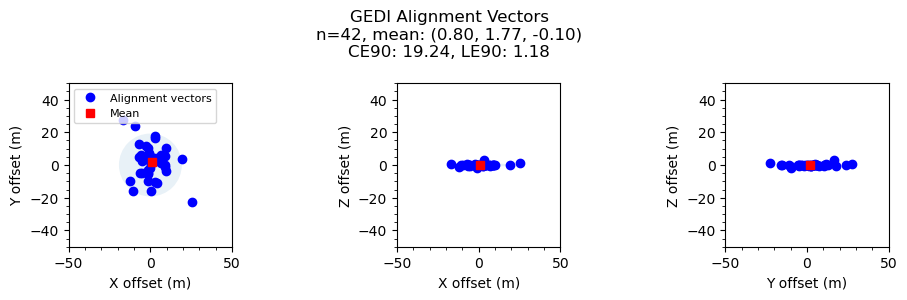

In [48]:
#make_plot3d(filter_gedi_dx,filter_gedi_dy,filter_gedi_dz,title_fig=f'GEDI Alignment Vectors',clim=(-50,50))
make_plot3d(filter_gedi_dx,filter_gedi_dy,filter_gedi_dz,title_fig=f'GEDI Alignment Vectors',clim=(-50,50),out_fn='/home/sbhusha1/notebooks/pcd/gedi_ce90_filter.png',figsize=(10,3))